In [1]:
import requests
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
from urllib.parse import urlencode
from concurrent.futures import ThreadPoolExecutor, as_completed
from pyrate_limiter import Duration, Rate, Limiter

In [2]:
# =========================================================
# Scraper function
# =========================================================
def scrape_bing_news_html(query: str, ticker: str, template: str, freshness: str = "Day"):
    base_url = "https://www.bing.com/news/search"

    params = {
        "q": query,
        "form": "HDRSC6",
        "qft": f'interval="{freshness}"'
    }

    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    url = f"{base_url}?{urlencode(params)}"

    try:
        limiter.try_acquire("bing_news")
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status()

        soup = BeautifulSoup(response.text, "html.parser")

        records = []

        # Bing markup can change, so these selectors may need updating
        cards = soup.select("div.news-card, div.t_s, div.newsitem, div.card-common")

        for card in cards:
            title = None
            link = None
            source = None
            snippet = None
            time_text = None
            image_url = None

            a = card.select_one("a.title") or card.select_one("a")
            if a:
                title = a.get_text(" ", strip=True)
                link = a.get("href")

            source_el = (
                card.select_one(".source")
                or card.select_one(".provider")
                or card.select_one("div.source")
                or card.select_one("span.source")
            )
            if source_el:
                source = source_el.get_text(" ", strip=True)

            snippet_el = (
                card.select_one(".snippet")
                or card.select_one(".caption")
                or card.select_one("div.snippet")
                or card.select_one("div.caption")
                or card.select_one("p")
            )
            if snippet_el:
                snippet = snippet_el.get_text(" ", strip=True)

            time_el = (
                card.select_one("span.time")
                or card.select_one(".time")
                or card.select_one("span")
            )
            if time_el:
                time_text = time_el.get_text(" ", strip=True)

            img_el = card.select_one("img")
            if img_el:
                image_url = img_el.get("src") or img_el.get("data-src")

            if title or link:
                records.append({
                    "ticker": ticker,
                    "template": template,
                    "query": query,
                    "freshness": freshness,
                    "search_url": url,
                    "title": title,
                    "url": link,
                    "source": source,
                    "snippet": snippet,
                    "time_text": time_text,
                    "image_url": image_url
                })

        return records

    except Exception as e:
        return [{
            "ticker": ticker,
            "template": template,
            "query": query,
            "freshness": freshness,
            "search_url": url,
            "title": None,
            "url": None,
            "source": None,
            "snippet": None,
            "time_text": None,
            "image_url": None,
            "error": str(e),
            "n_results_for_query": 0
        }]

In [3]:
TICKERS = """
AAPL
MSFT
GOOGL
AMZN
META
TSLA
NVDA
""".strip().splitlines()

QUERY_TEMPLATES = """
stock
earnings
outlook
analyst upgrade
analyst downgrade
forecast
sentiment
""".strip().splitlines()

FRESHNESS = "Day"   # often "Day", "Week", "Month"
MAX_RESULTS_PER_QUERY = 50
MAX_WORKERS = 5

limiter = Limiter(Rate(50, Duration.SECOND))

# =========================================================
# Build query list
# =========================================================
queries = []
for ticker in TICKERS:
    for template in QUERY_TEMPLATES:
        queries.append({
            "ticker": ticker,
            "template": template,
            "query": f"{ticker} {template}"
        })



# =========================================================
# Run all queries (parallel with rate limiting)
# =========================================================
all_records = []
query_stats = []

def _worker(row):
    ticker   = row["ticker"]
    template = row["template"]
    query    = row["query"]
    records  = scrape_bing_news_html(query=query, ticker=ticker, template=template, freshness=FRESHNESS)
    return ticker, template, query, records

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(_worker, row): i for i, row in enumerate(queries)}

    for done, fut in enumerate(as_completed(futures), start=1):
        ticker, template, query, records = fut.result()
        print(f"[{done}/{len(queries)}] {ticker} | {template}  ({len(records)} results)")

        n = len(records)
        has_error = n == 1 and records[0].get("error")

        if n == 0 or has_error:
            all_records.append({
                "ticker": ticker,
                "template": template,
                "query": query,
                "freshness": FRESHNESS,
                "search_url": None,
                "title": None,
                "url": None,
                "source": None,
                "snippet": None,
                "time_text": None,
                "image_url": None,
                "error": records[0].get("error") if records else None,
                "n_results_for_query": 0
            })
            query_stats.append({
                "ticker": ticker,
                "template": template,
                "query": query,
                "n_results": 0,
                "error": records[0].get("error") if records else None
            })
        else:
            for r in records[:MAX_RESULTS_PER_QUERY]:
                r["error"] = None
                r["n_results_for_query"] = n
                all_records.append(r)
            query_stats.append({
                "ticker": ticker,
                "template": template,
                "query": query,
                "n_results": n,
                "error": None
            })

[1/49] AAPL | outlook  (2 results)
[2/49] AAPL | earnings  (22 results)
[3/49] AAPL | analyst downgrade  (2 results)
[4/49] AAPL | stock  (24 results)
[5/49] AAPL | analyst upgrade  (2 results)
[6/49] AAPL | forecast  (0 results)
[7/49] AAPL | sentiment  (4 results)
[8/49] MSFT | stock  (24 results)
[9/49] MSFT | earnings  (14 results)
[10/49] MSFT | outlook  (6 results)
[11/49] MSFT | analyst upgrade  (0 results)
[12/49] MSFT | analyst downgrade  (0 results)
[13/49] MSFT | sentiment  (2 results)
[14/49] GOOGL | stock  (22 results)
[15/49] MSFT | forecast  (4 results)
[16/49] GOOGL | earnings  (12 results)
[17/49] GOOGL | analyst upgrade  (2 results)
[18/49] GOOGL | outlook  (0 results)
[19/49] GOOGL | forecast  (0 results)
[20/49] GOOGL | analyst downgrade  (0 results)
[21/49] GOOGL | sentiment  (0 results)
[22/49] AMZN | stock  (24 results)
[23/49] AMZN | analyst upgrade  (2 results)
[24/49] AMZN | earnings  (16 results)
[25/49] AMZN | outlook  (0 results)
[26/49] AMZN | analyst down

In [4]:
# =========================================================
# Build dataframes
# =========================================================
df = pd.DataFrame(all_records)
df_query_stats = pd.DataFrame(query_stats)

# Deduped by URL
df = (
    df.dropna(subset=["url"])
      .drop_duplicates(subset=["url"])
      .sort_values(by=["ticker", "template"])
      .reset_index(drop=True)
)

display(df)

,ticker,template,query,freshness,search_url,title,url,source,snippet,time_text,image_url,error,n_results_for_query
0,AAPL,analyst downgrade,AAPL analyst downgrade,Day,https://www.bing.com/news/search?q=AAPL+analys...,"SA analyst upgrades/downgrades: TSLA, AMZN, AA...",https://www.msn.com/en-us/money/topstocks/sa-a...,2d on MSN,Tesla (TSLA) and Amazon (AMZN) have received u...,,/th?id=OJ.x77cVnOcZaJPEg&pid=news&w=81&h=16&rs=2,None,2
1,AAPL,earnings,AAPL earnings,Day,https://www.bing.com/news/search?q=AAPL+earnin...,Apple (AAPL) Sees a More Significant Dip Than ...,https://finance.yahoo.com/markets/stocks/artic...,20h,Apple (AAPL) reached $275.15 at the closing of...,,/th?id=ONUT.2jHBuTdaQoJfuKex9AD59Q&pid=News&w=...,None,22
2,AAPL,earnings,AAPL earnings,Day,https://www.bing.com/news/search?q=AAPL+earnin...,Apple’s Target Climbs as Earnings Accelerate: ...,https://finance.yahoo.com/markets/stocks/artic...,1d,Apple (NASDAQ:AAPL) has become one of the more...,,/th?id=ONUT.D72QicxalNIz8PsKXXpvIA&pid=News&w=...,None,22
3,AAPL,earnings,AAPL earnings,Day,https://www.bing.com/news/search?q=AAPL+earnin...,AAPL earnings: Gene Munster says he has modest...,https://www.msn.com/en-us/money/topstocks/aapl...,Hosted on MSN 1mon,・Deepwater Asset Management’s Gene Munster sai...,,None,None,22
4,AAPL,earnings,AAPL earnings,Day,https://www.bing.com/news/search?q=AAPL+earnin...,AAPL earnings ahead: Prediction markets bet on...,https://seekingalpha.com/news/4582969-aapl-ear...,Seeking Alpha 1mon,Investors are turning their attention to Apple...,,None,None,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,TSLA,stock,TSLA stock,Day,https://www.bing.com/news/search?q=TSLA+stock&...,"TSLA's 5-Day Win Streak: AI5 Chip, Terafab & U...",https://www.zacks.com/stock/news/2901361/tslas...,zacks 2mon,"TSLA stock rose over 7% yesterday, marking a 5...",,None,None,24
190,TSLA,stock,TSLA stock,Day,https://www.bing.com/news/search?q=TSLA+stock&...,Tesla: The Stock Market's Valuation Laws Don't...,https://seekingalpha.com/article/4891659-tesla...,Seeking Alpha 2mon,"Tesla, Inc. is an AI and robotics platform wit...",,None,None,24
191,TSLA,stock,TSLA stock,Day,https://www.bing.com/news/search?q=TSLA+stock&...,How to Buy Tesla Stock (TSLA) in 2026,https://www.fool.com/investing/how-to-invest/s...,3mon,Get step-by-step guidance on how to invest in ...,,/th?id=OJ.c33IPqDhLTGl0w&pid=news&w=58&h=16&rs=2,None,24
192,TSLA,stock,TSLA stock,Day,https://www.bing.com/news/search?q=TSLA+stock&...,Tesla stock slips below $400: why upbeat EV sa...,https://invezz.com/news/2026/06/17/tesla-stock...,9d,The stock slipping below $400 despite upbeat n...,,/th?id=ONUT._s-SkgFbu32Zz5aJ1VAklQ&pid=News&w=...,None,24


In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

# Downloads ~500MB on first run, then cached at ~/.cache/huggingface/hub
MODEL = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)
model.eval()
print("Labels:", model.config.id2label)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Labels: {0: 'positive', 1: 'negative', 2: 'neutral'}


In [6]:
def get_sentiment(texts: list) -> pd.DataFrame:
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=512, return_tensors="pt")
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = F.softmax(logits, dim=-1)
    labels = model.config.id2label
    rows = [
        {"text": t, **{labels[i]: round(p.item(), 4) for i, p in enumerate(prob)}}
        for t, prob in zip(texts, probs)
    ]
    df = pd.DataFrame(rows)
    label_cols = list(model.config.id2label.values())
    df["score"] = df.positive - df.negative
    df["prediction"] = df[label_cols].idxmax(axis=1)
    return df

titles = df["title"].fillna("").tolist()
df_sent = get_sentiment(titles)
df2 = pd.concat([df, df_sent], axis=1)

sent = (
    df2.groupby("ticker")
      .apply(lambda g: np.average(
          g["score"],
          #weights=g["weight"]
      ))
)
sent = sent.sort_values(ascending=False)
print(sent)

ticker
META    -0.012608
TSLA    -0.013357
AAPL    -0.093174
GOOGL   -0.101600
NVDA    -0.145259
MSFT    -0.146224
AMZN    -0.187675
dtype: float64


C:\Users\Graham West\AppData\Local\Temp\ipykernel_31108\991702379.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(


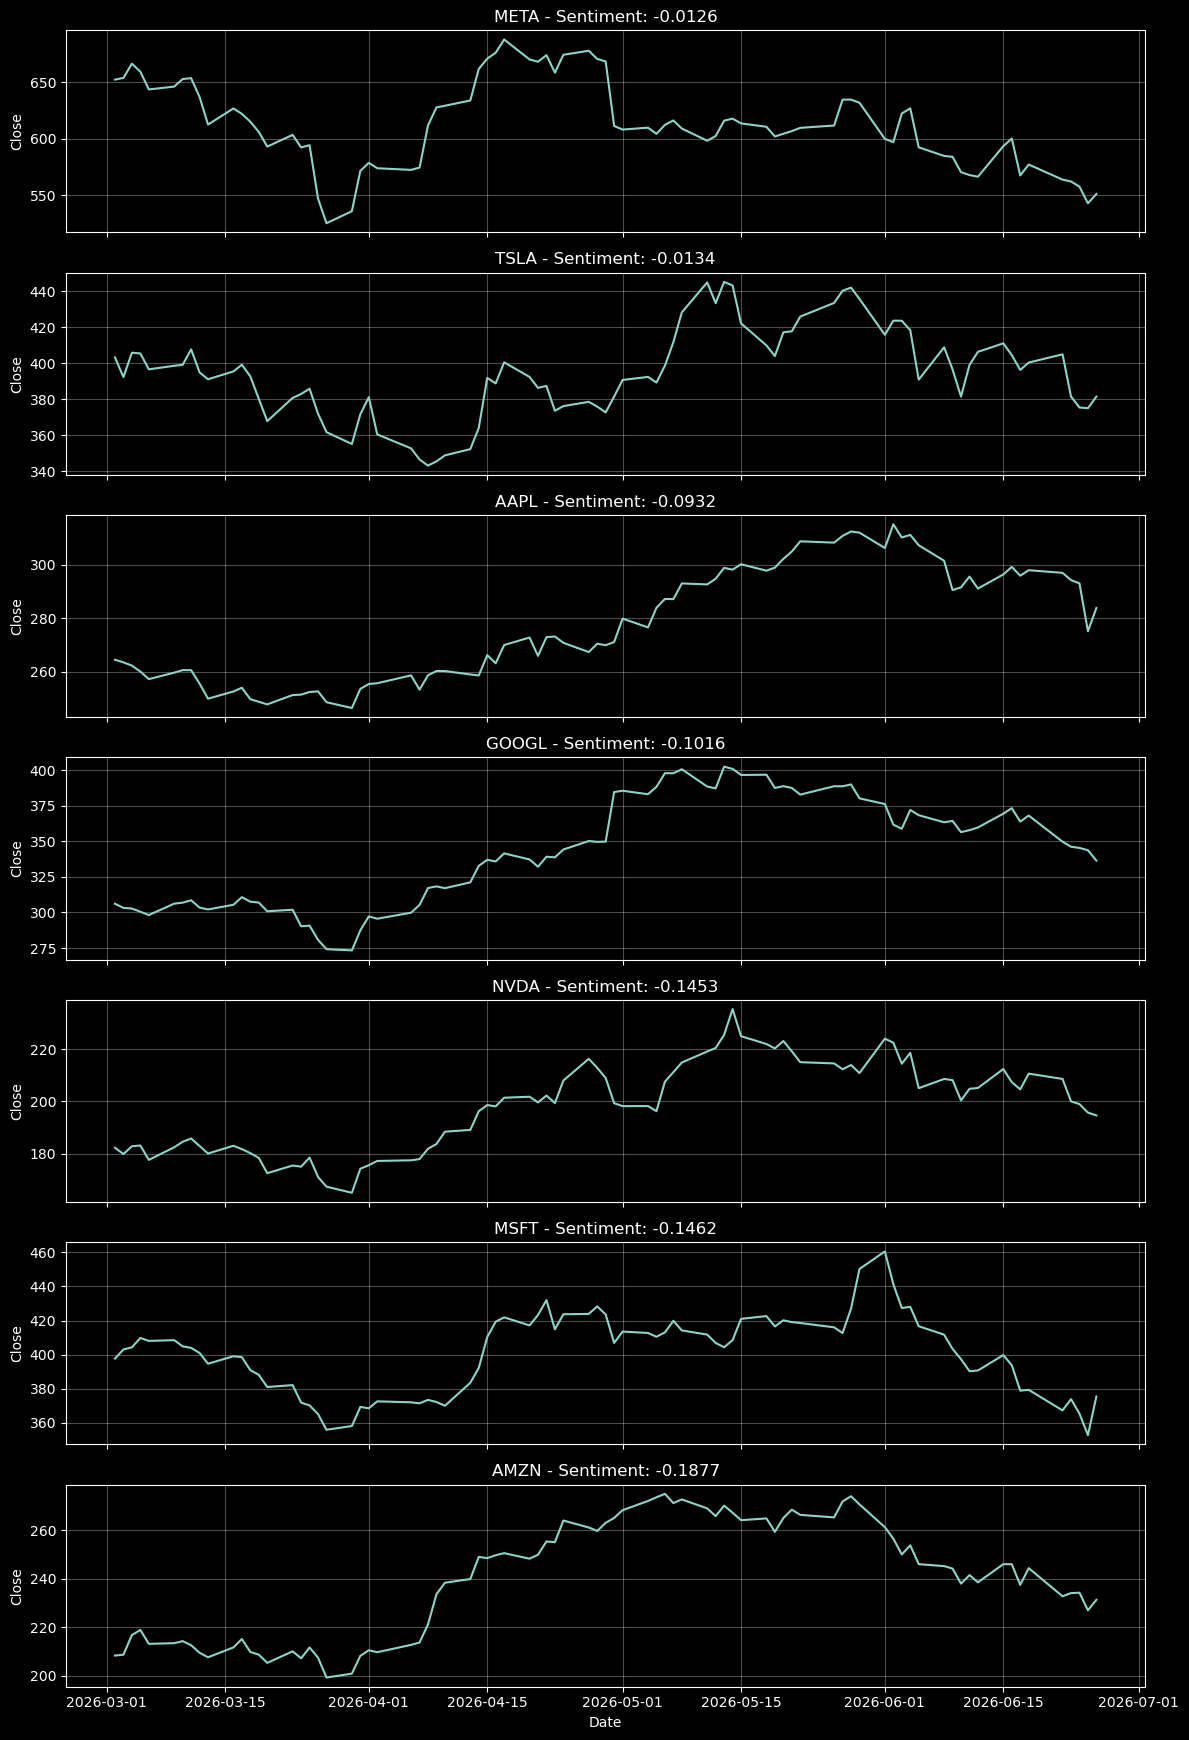

In [7]:
import yfinance as yf
import matplotlib.pyplot as plt
plt.style.use("dark_background")

START_DATE = "2026-03-01"

# --- Download data ---
df_yf = yf.download(
    TICKERS,
    start=START_DATE,
    interval="1d",
    group_by="ticker",
    auto_adjust=True,
    progress=False,
)

# --- Create subplots ---
n = len(TICKERS)

fig, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(12, 2.5 * n),
    sharex=True,
)

# If only one ticker, axes isn't a list
if n == 1:
    axes = [axes]

# --- Plot ---
for ax, ticker in zip(axes, sent.index):

    if ticker in df_yf.columns.get_level_values(0):
        close = df_yf[ticker]["Close"]

        ax.plot(close.index, close.values)

        ax.set_title(f"{ticker} - Sentiment: {sent.get(ticker, 0):.4f}")
        ax.set_ylabel("Close")

        ax.grid(True, alpha=0.3)

plt.xlabel("Date")
plt.tight_layout()

plt.show()